<a href="https://colab.research.google.com/github/IGiovanniRamirez/Giovanni-Ramirez-Data-Portfolio/blob/main/Project_Landing_Experiment%20A-B/Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentarios**:

- El dataset no tiene valores ausentes, no se ven valores nulos en ninguna de sus columnas, es un dataset con 40.000 filas y en todas sus columnas los datos están completos.
- La columna fecha (date) es de tipo de dato texto (object) y debería de ser tipo fecha, se debe corregir a datetime64.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print('Numero de usuarios duplicados:', df["user_id"].duplicated().sum())
print('Numero de usuarios únicos:', df["user_id"].nunique())

Numero de usuarios duplicados: 0
Numero de usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas y conversión del tipo de dato de la columna a datetime64

In [ ]:
# Resumen estadístico y conversión tipo de dato
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Verificación de cambio en el tipo de dato de la columna date**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
print("Resumen estadístico del gasto (todos los usuarios):")
df['gasto'].describe()

Resumen estadístico del gasto (todos los usuarios):


count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que si convirtieron
usuarios_convertidos = df[df['converted'] == 1]
print("Resumen estadístico del gasto (solo usuarios convertidos):")
usuarios_convertidos['gasto'].describe()

Resumen estadístico del gasto (solo usuarios convertidos):


count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
columnas_categoricas = ["landing", "region", "dispositivo", "traffic_source", "user_type"]
# Seleccionar las columnas y ver conteos
for columna in columnas_categoricas:
    print(f"\n{columna.upper()}:")
    print(df[columna].value_counts())


Conteo de categorías:

LANDING:
B    20018
A    19982
Name: landing, dtype: int64

REGION:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

DISPOSITIVO:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

TRAFFIC_SOURCE:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

USER_TYPE:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentarios:**
- Al revisar el conteo de las columnas categóricas no se ven valores anómalos; todas las columnas tienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t-Student (t-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los clientes es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los clientes es diferente en la página A y la página B.

In [ ]:
# Aplicar prueba

t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados

print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico t: -9.36563589591332
Valor P: 1.0635288333792346e-20
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
- Se rechaza la hipótesis nula

**Interpretación de negocio:**  
- El estadístico t (-9.37) nos muestra que estadísticamente se comprueba que hay una diferencia muy grande entre el gasto promedio de la página A y la página B (Si el estadístico t es cercano a 0 indica que no hay diferencia, pero si es muy positivo o muy negativo, indica que hay una diferencia grande). En este caso el estadístico t es negativo lo que significa que el primer grupo (probablemente página A) tiene un gasto promedio menor que el segundo grupo (página B).
- El valor P (1.06e-20) es prácticamente cero, indica que podemos estar 99.99999...% seguros de que hay una diferencia grande entre el gasto promedio de la página A y la página B, por lo cual en este caso tenemos suficiente evidencia para rechazar la hipótesis nula. Para tener en cuenta los criterios son los siguientes:
  -  Si el valor p (p-value) < 0.05 se rechaza H₀ (hipótesis nula) porque representa una fuerte evidencia de que existe una diferencia entre los datos que no es producto del azar.
  -  Si el valor p (p-value) > 0.05 no se rechaza H₀ (hipótesis nula) porque representa una fuerte evidencia de que **NO** existe una diferencia entre los datos y la diferencia observada podría explicarse por el azar (podría ser casualidad).
  -  Si el valor p (p-value) < 0.001 inddica una diferencia MUY significativa.
  -  Si el valor p (p-value) ≈ 0 indica una diferencia EXTREMADAMENTE significativa.
  



---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalúa si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y en la página B. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente en la página A y en la página B. Hay un factor que influye en la decisión de compra.

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]
z_stat, p_value = proportions_ztest(exitos , observaciones)
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]
# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

print(f"\nTasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%


### 📝 Conclusión e interpretación

**Decisión:**  

- Se rechaza la hipótesis nula

**Interpretación de negocio:**  

- El estadístico Z es negativo (-9.68) indica que la página A tiene una tasa de conversión **MENOR** que la página B, es decir, la página B convierte **MEJOR** que la página A (diferencia enorme, muy alejada de 0, cualquier |Z| > 2.58 es muy significativo).
- El valor P (3.76e-22) es prácticamente cero, indica que podemos estar 99.99999...% seguros de que hay una diferencia grande en la tasa de conversión entre la página A y B, por lo cual en este caso tenemos suficiente evidencia para rechazar la hipótesis nula. Para tener en cuenta los criterios son los siguientes:
   - Valor p bajo → Hay evidencia estadística contra la hipótesis nula.
   - Valor p alto → No hay evidencia suficiente para afirmar una diferencia en conversión
- Es importante mencionar que este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar un cambio en el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada para variables categóricas

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables fuente de tráfico y conversión (La conversión es independiente de la fuente de donde proviene el cliente).
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las variables fuente de tráfico y conversión (La conversión depende de la fuente de donde proviene el cliente).

In [ ]:
# Aplicar prueba
tabla = pd.crosstab( df["traffic_source"], df["converted"])
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  



- Se rechaza la hipótesis nula

**Interpretación de negocio:**  

- El valor P (0.034) muestra que existe evidencia estadísticamente significativa de que la conversión **SÍ** depende de la fuente de tráfico, con un 96.6% de confianza de que la relación es real, solo 3.4% de probabilidad de que sea casualidad, por lo que se rechaza la hipótesis nula.
- chi-cuadrado = 8.662 con 3 grados de libertad (4 fuentes de tráfico, 4 - 1 = 3 grados de libertad) indica una asociación moderada y que hay alguna diferencia entre canales, no es una diferencia enorme, pero sí prácticamente significativa.
- Las frecuencias esperadas representan lo que veríamos si todos los canales fueran iguales.


Para tener en cuenta los criterios son los siguientes:
  -  Si el valor p (p-value) < 0.05 se rechaza H₀ (hipótesis nula) porque los conteos observados serían poco probables bajo independencia y hay evidencia estadística contra la hipótesis nula.
  -  Si el valor p (p-value) > 0.05 no se rechaza H₀ (hipótesis nula) porque los conteos observados son compatibles con independencia y no hay evidencia suficiente de asociación.



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada para variables categóricas

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables tipo de usuario y conversión (La conversión es independiente de si el cliente es nuevo o recurrente).
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las variables tipo de usuario y conversión (La conversión dependede de si el cliente es nuevo o recurrente).

In [ ]:
# Aplicar prueba
tabla = pd.crosstab( df["user_type"], df["converted"])
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
-  No se rechaza la hipótesis nula

**Interpretación de negocio:**  

- El valor P (0.474) muestra que **NO** existe evidencia estadísticamente significativa de que el tipo de usuario (nuevo vs. recurrente) influya en la conversión, por lo que **NO** se rechaza la hipótesis nula. Los usuarios nuevos y recurrentes convierten a tasas SIMILARES y el historial de visitas previas NO predice la conversión actual.
- chi-cuadrado = 0.513 con 1 grado de libertad (2 tipos de usuario, 2 - 1 = 1 grado de libertad) indica que las diferencias son mínimas.
- Las frecuencias esperadas representan lo que veríamos si no hubiera diferencia entre tipos de usuario.


Para tener en cuenta los criterios son los siguientes:
  -  Si el valor p (p-value) < 0.05 se rechaza H₀ (hipótesis nula) porque los conteos observados serían poco probables bajo independencia y hay evidencia estadística contra la hipótesis nula.
  -  Si el valor p (p-value) > 0.05 no se rechaza H₀ (hipótesis nula) porque los conteos observados son compatibles con independencia y no hay evidencia suficiente de asociación.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

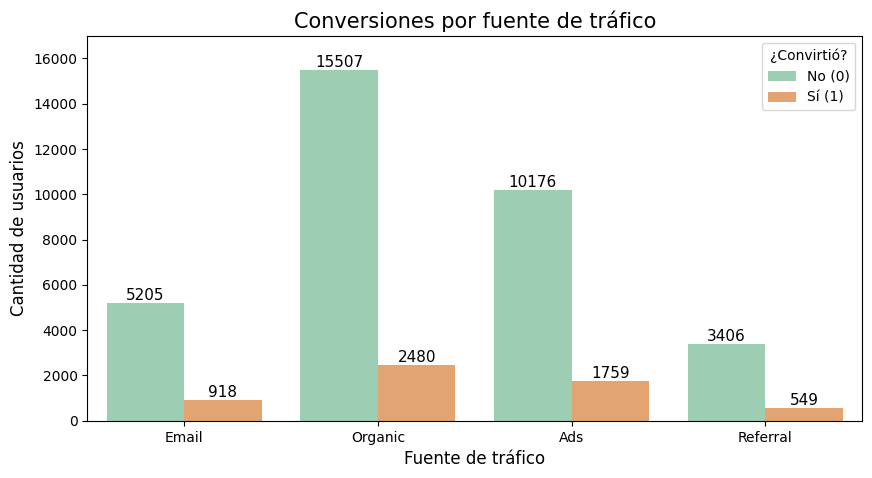

In [ ]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"] )
# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente
# Añadir detalles
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,17000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**:

- La visualización corrobora el hallazgo estadístico: la fuente de tráfico influye significativamente en las conversiones. El gráfico muestra claramente que el tráfico orgánico y la publicidad (ads) generan la mayor cantidad de conversiones, superando notablemente a email y referidos. Esta diferencia visual refuerza los resultados de la prueba chi-cuadrado, que con un 96.6% de confianza demostró que la conversión SÍ depende de la fuente de tráfico, representando un insight clave para la optimización de la estrategia de marketing digital.

### Relación entre el tipo de usuario y la conversión

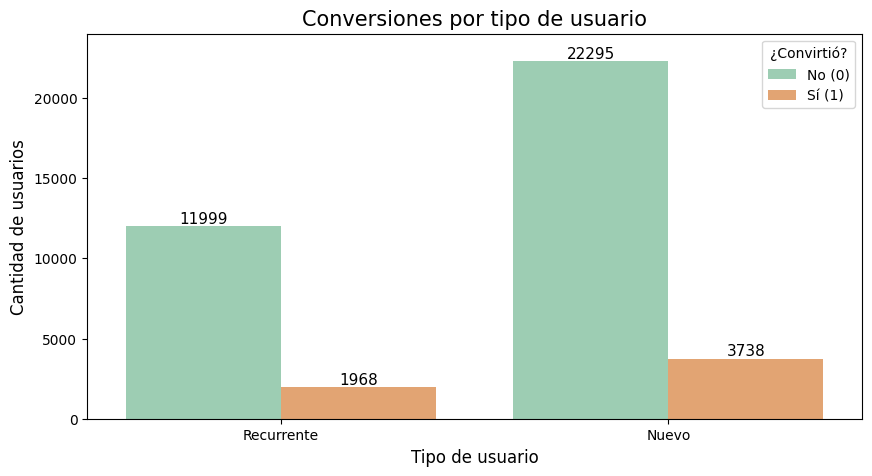

In [ ]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"] )
# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                     # Alinear centro del texto en coordenada
            va='bottom',                   # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente
# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,24000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**:

- La visualización en barras agrupadas corrobora el hallazgo estadístico: no existe una diferencia significativa en el comportamiento de conversión entre usuarios nuevos y recurrentes. Si bien los usuarios nuevos muestran más conversiones en términos absolutos, esto refleja únicamente que representan un mayor porcentaje de la base de usuarios, no una mayor probabilidad de conversión. Este patrón visual refuerza la conclusión de la prueba chi-cuadrado, donde no se encontró evidencia suficiente de asociación entre ambas variables.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La versión B generó un gasto promedio significativamente mayor que la versión A entre los usuarios que realizaron compra (prueba t-student, t = -9.37, p ≈ 0.000).
- La diferencia no es producto del azar; el nivel de significancia es extremadamente alto (p < 0.001), lo que indica una diferencia robusta y consistente.

**Interpretación:**
 - La página B no solo convierte más, sino que además genera mayor valor económico por cliente. Desde la perspectiva de revenue, B es claramente superior.
<br>

**Tasa de conversión:**
- La versión B obtuvo más conversiones (3194) que la versión A (2512), con tamaños de muestra prácticamente iguales.
- La diferencia en tasa de conversión es estadísticamente significativa (prueba Z,  Z = -9.68, p ≈ 0.000).

**Interpretación:**
- La página B convierte significativamente mejor que la página A. El resultado es sólido y consistente estadísticamente, lo que reduce el riesgo de implementar la versión B.
  
---

#### 📊 **Segmentación por fuente de tráfico**
- Existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión (Prueba chi-cuadrada = 8.66, p = 0.034).
- Los canales Organic y Ads concentran el mayor volumen de conversiones, mientras que Email y Referral muestran menor impacto relativo.

**Interpretación:**
- La conversión depende del canal de adquisición. Esto abre una oportunidad para optimizar la inversión en marketing digital priorizando los canales con mayor efectividad.

   ---

#### 📊 **Segmentación por tipo de usuario**
- No se encontró evidencia estadísticamente significativa de que el tipo de usuario (Nuevo vs Recurrente) influya en la conversión (p = 0.474).
  
**Interpretación:**
- La probabilidad de conversión es similar para usuarios nuevos y recurrentes. No hay justificación estadística para diseñar estrategias diferenciadas basadas únicamente en esta variable.

---

#### 📈 **Las visualizaciones confirman los hallazgos estadísticos:**

- Organic y Ads concentran mayor volumen de conversiones.
- No hay diferencias visibles relevantes entre usuarios nuevos y recurrentes en tasa de conversión.

---

#### 💡 **Recomendaciones de negocio:**
1. Implementar la versión B como versión oficial

La evidencia estadística es contundente:

 - Mayor tasa de conversión.
 - Mayor gasto promedio.
 - Diferencias altamente significativas.
 - Esto implica un impacto directo en ingresos y eficiencia del funnel.

2. Priorizar inversión en canales Organic y Ads

Dado que la conversión depende del canal, se recomienda:

 - Optimizar campañas en Ads (mejor segmentación y creatividades).
 - Fortalecer estrategia SEO para potenciar tráfico Organic.
 - Revisar estrategia de Email y Referral para mejorar su desempeño.

3. No segmentar estrategias únicamente por tipo de usuario

 - No hay evidencia de que nuevos y recurrentes conviertan distinto en este experimento.
 - Se recomienda enfocar esfuerzos en optimización de experiencia y adquisición, más que en diferenciación por historial.

#### 🎯 **Decisión Final**

Desde una perspectiva estadística y de negocio, la versión B debe implementarse.

Genera:

- Más conversiones
- Mayor ingreso por usuario
- Resultados estadísticamente sólidos
- La decisión tiene bajo riesgo analítico y alto potencial de impacto económico.